In [ ]:
# Import libraries
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [ ]:
# Upload dataset
from google.colab import files
uploaded = files.upload()

Saving Hotel-A-test.csv to Hotel-A-test.csv
Saving Hotel-A-train.csv to Hotel-A-train.csv
Saving Hotel-A-validation.csv to Hotel-A-validation.csv


In [ ]:
# Load dataset
train_df = pd.read_csv("Hotel-A-train.csv")

In [ ]:
# Show first rows
print("First 5 rows:")
print(train_df.head())

First 5 rows:
   Reservation-id Gender  Age         Ethnicity Educational_Level  \
0        39428300      F   40            Latino              Grad   
1        77491756      F   49            Latino        Mid-School   
2        73747291      F   42         caucasian              Grad   
3        67301739      M   25  African American           College   
4        77222321      F   62            Latino       High-School   

        Income Country_region      Hotel_Type Expected_checkin  \
0         <25K          North      City Hotel        7/01/2015   
1  50K -- 100K           East      City Hotel        7/01/2015   
2         <25K           East      City Hotel        7/02/2015   
3        >100K          South  Airport Hotels        7/02/2015   
4    25K --50K           East          Resort        7/03/2015   

  Expected_checkout  ... Meal_Type  Visted_Previously  Previous_Cancellations  \
0         7/02/2015  ...        BB                 No                      No   
1         7/

In [ ]:
# Summary statistics for numerical variables
print("Summary Statistics:")
print(train_df.describe())

Summary Statistics:
       Reservation-id           Age        Adults      Children        Babies  \
count    2.749900e+04  27499.000000  27499.000000  27499.000000  27499.000000   
mean     5.016461e+07     43.977454      2.333576      1.743882      0.351540   
std      2.886911e+07     15.303148      1.176526      0.721972      0.573326   
min      3.154000e+03     18.000000      1.000000      1.000000      0.000000   
25%      2.523943e+07     31.000000      2.000000      1.000000      0.000000   
50%      5.014996e+07     44.000000      2.000000      2.000000      0.000000   
75%      7.518288e+07     57.000000      3.000000      2.000000      1.000000   
max      9.999900e+07     70.000000      5.000000      3.000000      2.000000   

       Discount_Rate     Room_Rate  
count   27499.000000  27499.000000  
mean       12.495182    175.136478  
std        11.206036     43.877087  
min         0.000000    100.000000  
25%         5.000000    137.000000  
50%        10.000000    175.

In [ ]:
# Reservation status distribution
status_counts = train_df["Reservation_Status"].value_counts()

print("Reservation Status Distribution:")
print(status_counts)

Reservation Status Distribution:
Reservation_Status
Check-Out    21240
Canceled      4134
No-Show       2125
Name: count, dtype: int64


In [ ]:
# Percentage distribution
status_percent = train_df["Reservation_Status"].value_counts(normalize=True) * 100

print("\nReservation Status Percentage:")
print(status_percent)


Reservation Status Percentage:
Reservation_Status
Check-Out    77.239172
Canceled     15.033274
No-Show       7.727554
Name: proportion, dtype: float64


In [ ]:
# Reservation status by hotel type
hotel_status = pd.crosstab(train_df["Hotel_Type"], train_df["Reservation_Status"])

print("Reservation Status by Hotel Type:")
print(hotel_status)

Reservation Status by Hotel Type:
Reservation_Status  Canceled  Check-Out  No-Show
Hotel_Type                                      
Airport Hotels          1330       7219      709
City Hotel              1362       7057      715
Resort                  1442       6964      701


In [ ]:
# Percentage comparison
hotel_status_percent = pd.crosstab(train_df["Hotel_Type"], train_df["Reservation_Status"], normalize='index') * 100

print("\nReservation Status Percentage by Hotel Type:")
print(hotel_status_percent)


Reservation Status Percentage by Hotel Type:
Reservation_Status   Canceled  Check-Out   No-Show
Hotel_Type                                        
Airport Hotels      14.365954  77.975805  7.658242
City Hotel          14.911320  77.260784  7.827896
Resort              15.833974  76.468650  7.697376


In [ ]:
# Previous cancellation behaviour
prev_cancel = train_df["Previous_Cancellations"].value_counts()

print("Previous Cancellation Behaviour:")
print(prev_cancel)

Previous Cancellation Behaviour:
Previous_Cancellations
No     24379
Yes     3120
Name: count, dtype: int64


In [ ]:
# Missing values check
missing_values = train_df.isnull().sum()

print("Missing values per column:")
print(missing_values)

print("\nTotal missing values in dataset:")
print(missing_values.sum())

Missing values per column:
Reservation-id            0
Gender                    0
Age                       0
Ethnicity                 0
Educational_Level         0
Income                    0
Country_region            0
Hotel_Type                0
Expected_checkin          0
Expected_checkout         0
Booking_date              0
Adults                    0
Children                  0
Babies                    0
Meal_Type                 0
Visted_Previously         0
Previous_Cancellations    0
Deposit_type              0
Booking_channel           0
Required_Car_Parking      0
Reservation_Status        0
Use_Promotion             0
Discount_Rate             0
Room_Rate                 0
dtype: int64

Total missing values in dataset:
0


In [ ]:
# Duplicate rows check
duplicates = train_df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


Reservation_Status
Check-Out    21240
Canceled      4134
No-Show       2125
Name: count, dtype: int64


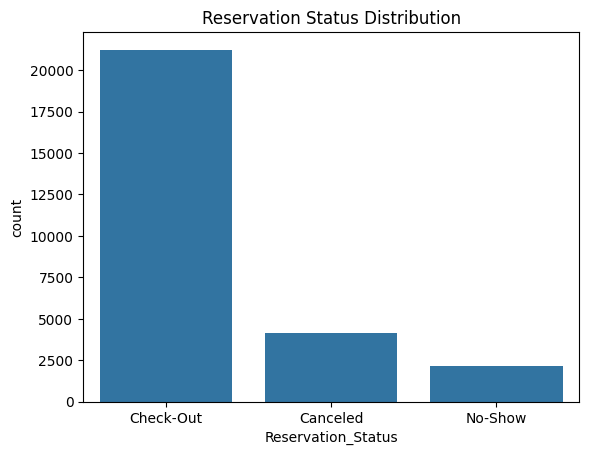

In [ ]:
# Pattern Identification (Train Dataset)
#Reservation Status Distribution
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
train_df = pd.read_csv("Hotel-A-train.csv")

# Count reservation status
print(train_df["Reservation_Status"].value_counts())

# Plot
sns.countplot(x="Reservation_Status", data=train_df)
plt.title("Reservation Status Distribution")
plt.show()

Reservation_Status  Canceled  Check-Out  No-Show
Hotel_Type                                      
Airport Hotels          1330       7219      709
City Hotel              1362       7057      715
Resort                  1442       6964      701


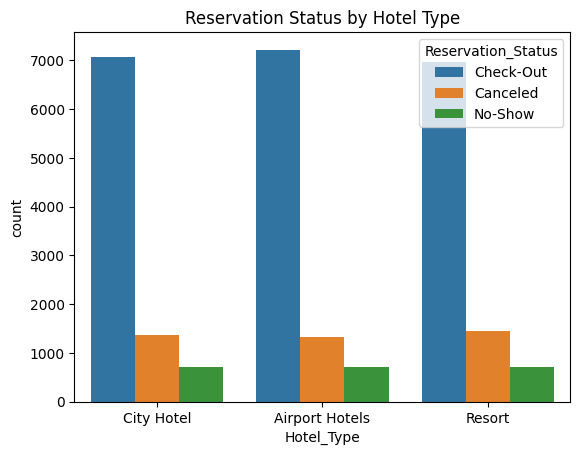

In [ ]:
#Reservation Status by Hotel Type
# Crosstab table
print(pd.crosstab(train_df["Hotel_Type"], train_df["Reservation_Status"]))

# Plot
sns.countplot(x="Hotel_Type", hue="Reservation_Status", data=train_df)
plt.title("Reservation Status by Hotel Type")
plt.show()

Previous_Cancellations
No     24379
Yes     3120
Name: count, dtype: int64


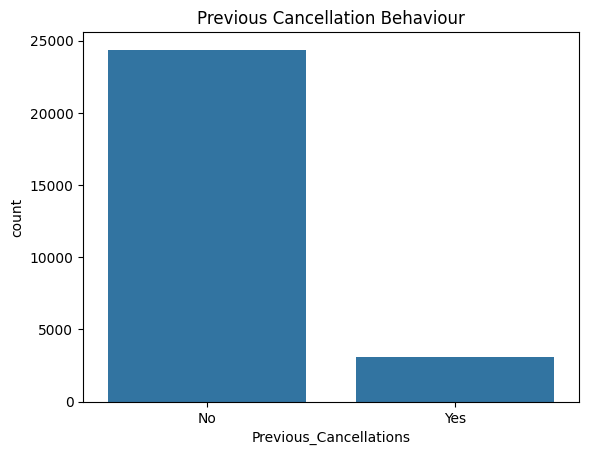

In [ ]:
#Previous Cancellation Behaviour
# Count previous cancellations
print(train_df["Previous_Cancellations"].value_counts())

# Plot
sns.countplot(x="Previous_Cancellations", data=train_df)
plt.title("Previous Cancellation Behaviour")
plt.show()

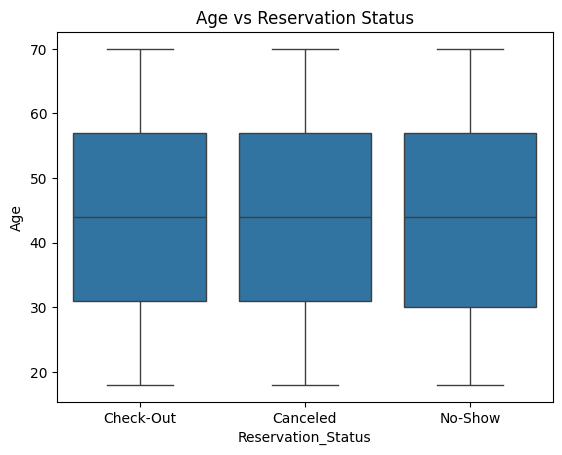

In [ ]:
#Age Distribution
sns.boxplot(x="Reservation_Status", y="Age", data=train_df)
plt.title("Age vs Reservation Status")
plt.show()

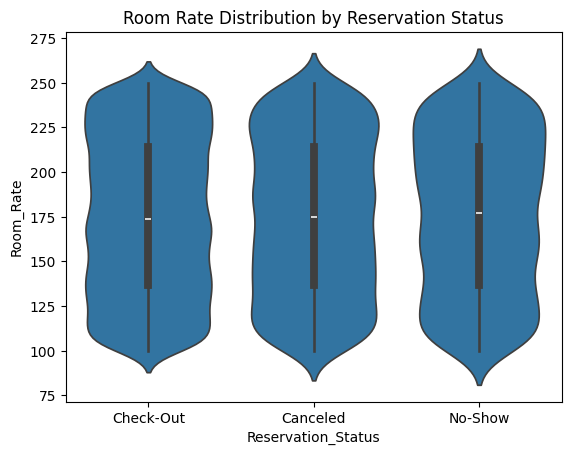

In [ ]:
#Room Rate Distribution
sns.violinplot(x="Reservation_Status", y="Room_Rate", data=train_df)
plt.title("Room Rate Distribution by Reservation Status")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [ ]:
from google.colab import files
uploaded = files.upload()

train = pd.read_csv("Hotel-A-train.csv")
test = pd.read_csv("Hotel-A-test.csv")
validation = pd.read_csv("Hotel-A-validation.csv")

train.head()

Saving Hotel-A-test.csv to Hotel-A-test (1).csv
Saving Hotel-A-train.csv to Hotel-A-train (1).csv
Saving Hotel-A-validation.csv to Hotel-A-validation (1).csv


,Reservation-id,Gender,Age,Ethnicity,Educational_Level,Income,Country_region,Hotel_Type,Expected_checkin,Expected_checkout,...,Meal_Type,Visted_Previously,Previous_Cancellations,Deposit_type,Booking_channel,Required_Car_Parking,Reservation_Status,Use_Promotion,Discount_Rate,Room_Rate
0,39428300,F,40,Latino,Grad,<25K,North,City Hotel,7/01/2015,7/02/2015,...,BB,No,No,No Deposit,Online,Yes,Check-Out,Yes,10,218
1,77491756,F,49,Latino,Mid-School,50K -- 100K,East,City Hotel,7/01/2015,7/02/2015,...,BB,No,No,Refundable,Online,Yes,Check-Out,No,0,185
2,73747291,F,42,caucasian,Grad,<25K,East,City Hotel,7/02/2015,7/06/2015,...,BB,No,No,No Deposit,Online,Yes,Check-Out,No,0,119
3,67301739,M,25,African American,College,>100K,South,Airport Hotels,7/02/2015,7/03/2015,...,BB,No,No,Refundable,Agent,Yes,Check-Out,Yes,5,144
4,77222321,F,62,Latino,High-School,25K --50K,East,Resort,7/03/2015,7/04/2015,...,BB,No,No,No Deposit,Direct,No,Check-Out,Yes,10,242


In [ ]:
# Shape of dataset
print("Train shape:", train.shape)

# Column information
train.info()

# Summary statistics
train.describe()

Train shape: (27499, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27499 entries, 0 to 27498
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Reservation-id          27499 non-null  int64 
 1   Gender                  27499 non-null  object
 2   Age                     27499 non-null  int64 
 3   Ethnicity               27499 non-null  object
 4   Educational_Level       27499 non-null  object
 5   Income                  27499 non-null  object
 6   Country_region          27499 non-null  object
 7   Hotel_Type              27499 non-null  object
 8   Expected_checkin        27499 non-null  object
 9   Expected_checkout       27499 non-null  object
 10  Booking_date            27499 non-null  object
 11  Adults                  27499 non-null  int64 
 12  Children                27499 non-null  int64 
 13  Babies                  27499 non-null  int64 
 14  Meal_Type               27499

,Reservation-id,Age,Adults,Children,Babies,Discount_Rate,Room_Rate
count,2.749900e+04,27499.000000,27499.000000,27499.000000,27499.000000,27499.000000,27499.000000
mean,5.016461e+07,43.977454,2.333576,1.743882,0.351540,12.495182,175.136478
std,2.886911e+07,15.303148,1.176526,0.721972,0.573326,11.206036,43.877087
min,3.154000e+03,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000
25%,2.523943e+07,31.000000,2.000000,1.000000,0.000000,5.000000,137.000000
50%,5.014996e+07,44.000000,2.000000,2.000000,0.000000,10.000000,175.000000
75%,7.518288e+07,57.000000,3.000000,2.000000,1.000000,20.000000,214.000000
max,9.999900e+07,70.000000,5.000000,3.000000,2.000000,40.000000,250.000000


In [ ]:
# Missing values
train.isnull().sum()

,0
Reservation-id,0
Gender,0
Age,0
Ethnicity,0
Educational_Level,0
Income,0
Country_region,0
Hotel_Type,0
Expected_checkin,0
Expected_checkout,0


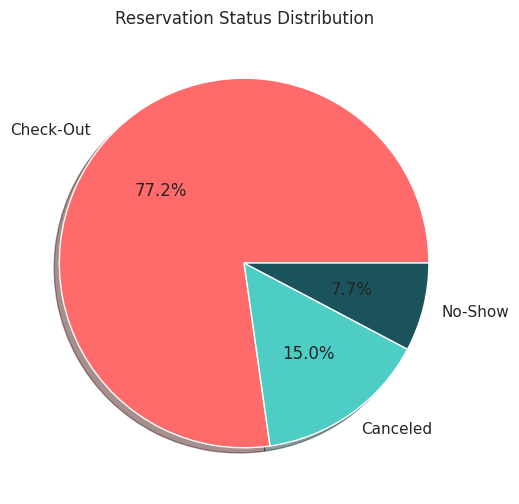

In [ ]:
#TRAIN DATASET
#Reservation Status Pie Chart
status_counts = train["Reservation_Status"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct="%1.1f%%",
    colors=["#ff6b6b","#4ecdc4","#1a535c"],
    shadow=True
)

plt.title("Reservation Status Distribution")
plt.show()

/tmp/ipykernel_8294/1363048083.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


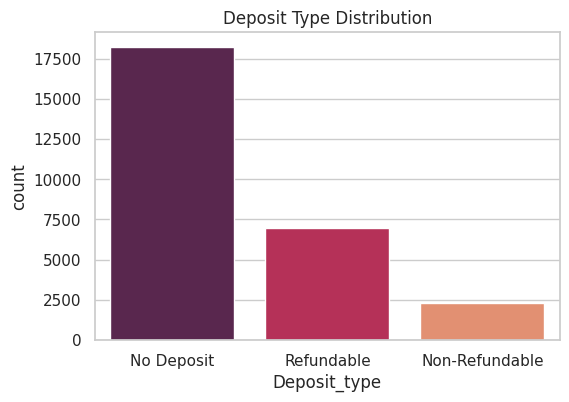

In [ ]:
#Deposit Type Bar Chart
plt.figure(figsize=(6,4))

sns.countplot(
    x="Deposit_type",
    data=train,
    palette="rocket"
)

plt.title("Deposit Type Distribution")
plt.show()

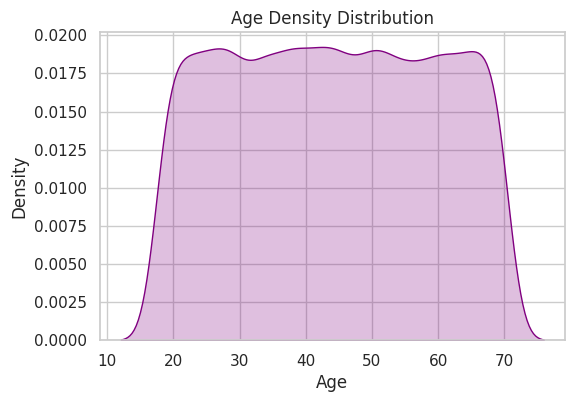

In [ ]:
#Age Density Plot
plt.figure(figsize=(6,4))

sns.kdeplot(
    train["Age"],
    fill=True,
    color="purple"
)

plt.title("Age Density Distribution")
plt.show()

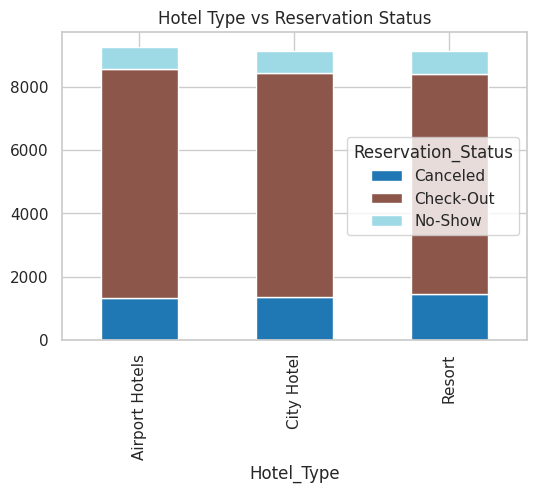

In [ ]:
#BIVARIATE ANALYSIS
#Hotel Type vs Reservation Status
ct = pd.crosstab(train["Hotel_Type"], train["Reservation_Status"])

ct.plot(
    kind="bar",
    stacked=True,
    figsize=(6,4),
    colormap="tab20"
)

plt.title("Hotel Type vs Reservation Status")
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 86.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 33.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 89.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 51.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 13.8% of the points cannot be plac

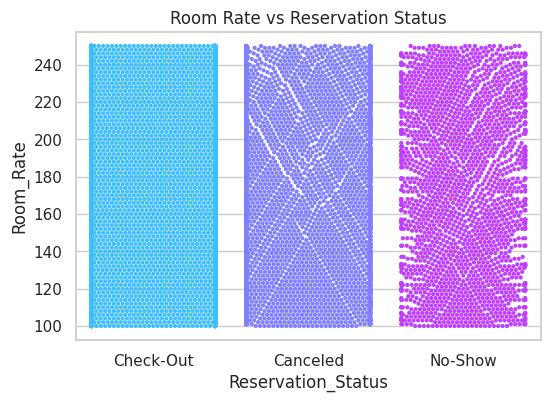

In [30]:
#Room Rate vs Reservation Status
plt.figure(figsize=(6,4))

sns.swarmplot(
    x="Reservation_Status",
    y="Room_Rate",
    data=train,
    hue="Reservation_Status",
    palette="cool",
    size=3
)

plt.title("Room Rate vs Reservation Status")
plt.legend([],[], frameon=False)
plt.show()

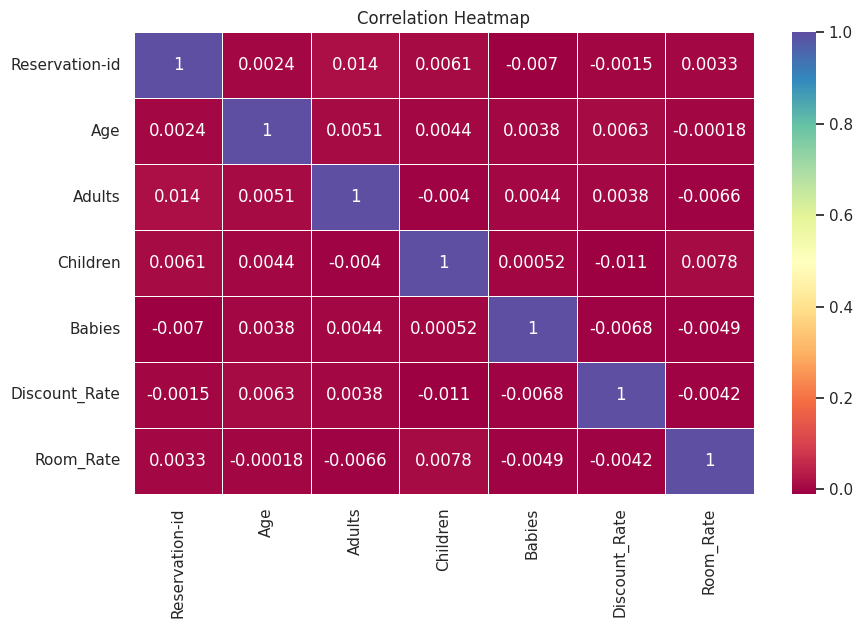

In [31]:
#MULTIVARIATE ANALYSIS
#Correlation Heatmap
plt.figure(figsize=(10,6))

corr = train.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="Spectral",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Correlation Heatmap")

plt.show()

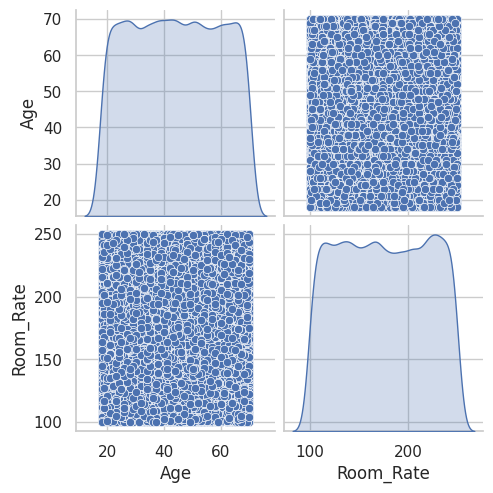

In [32]:
#Pairplot (Multiple Variable Relationships)
sns.pairplot(
    train[["Age","Room_Rate","Previous_Cancellations"]],
    diag_kind="kde"
)

plt.show()

In [33]:
#Further EDA section for the Train dataset
#Average Lead Time by Hotel Type

/tmp/ipykernel_8294/2779852598.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


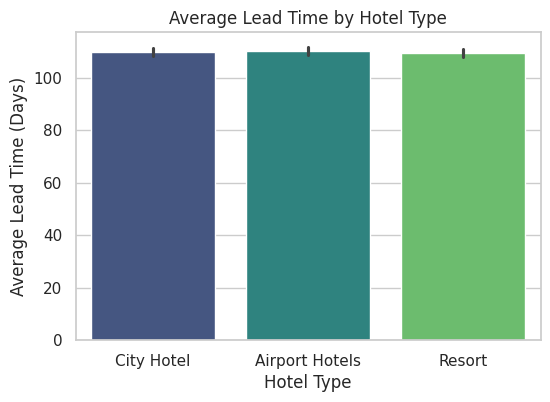

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert date columns to datetime objects first
train['Expected_checkin'] = pd.to_datetime(train['Expected_checkin'])
train['Booking_date'] = pd.to_datetime(train['Booking_date'])

# Calculate Lead_Time in days
train['Lead_Time'] = (train['Expected_checkin'] - train['Booking_date']).dt.days

plt.figure(figsize=(6,4))

sns.barplot(
    x="Hotel_Type",
    y="Lead_Time",
    data=train,
    palette="viridis"
)

plt.title("Average Lead Time by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Average Lead Time (Days)")

plt.show()

/tmp/ipykernel_8294/4126388326.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


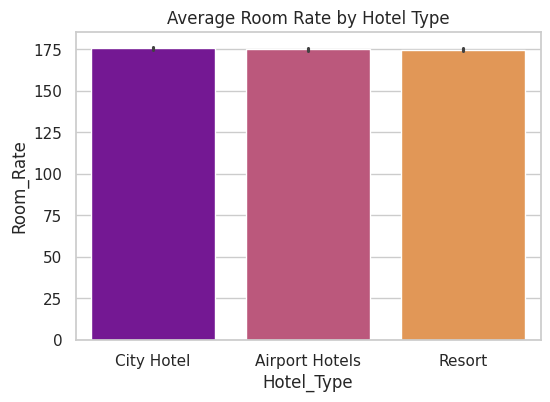

In [35]:
#Average Room Rate by Hotel Type
plt.figure(figsize=(6,4))

sns.barplot(
    x="Hotel_Type",
    y="Room_Rate",
    data=train,
    palette="plasma"
)

plt.title("Average Room Rate by Hotel Type")

plt.show()

/tmp/ipykernel_8294/3527762816.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


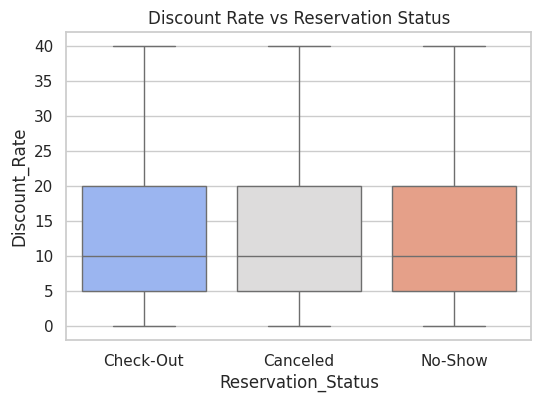

In [36]:
#Discount Rate vs Cancellation Behavior
plt.figure(figsize=(6,4))

sns.boxplot(
    x="Reservation_Status",
    y="Discount_Rate",
    data=train,
    palette="coolwarm"
)

plt.title("Discount Rate vs Reservation Status")

plt.show()

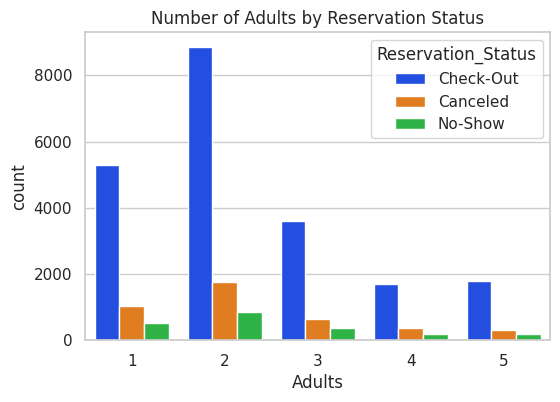

In [37]:
#Adults vs Reservation Status
plt.figure(figsize=(6,4))

sns.countplot(
    x="Adults",
    hue="Reservation_Status",
    data=train,
    palette="bright"
)

plt.title("Number of Adults by Reservation Status")

plt.show()

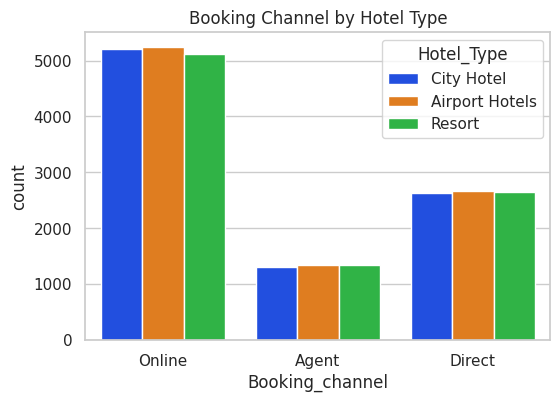

In [38]:
#Booking Channel vs Hotel Type
plt.figure(figsize=(6,4))

sns.countplot(
    x="Booking_channel",
    hue="Hotel_Type",
    data=train,
    palette="bright"
)

plt.title("Booking Channel by Hotel Type")

plt.show()

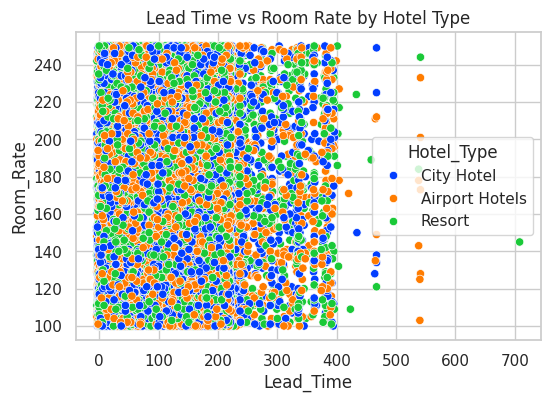

In [39]:
#Lead Time vs Room Rate
plt.figure(figsize=(6,4))

sns.scatterplot(
    x="Lead_Time",
    y="Room_Rate",
    hue="Hotel_Type",
    data=train,
    palette="bright"
)

plt.title("Lead Time vs Room Rate by Hotel Type")

plt.show()

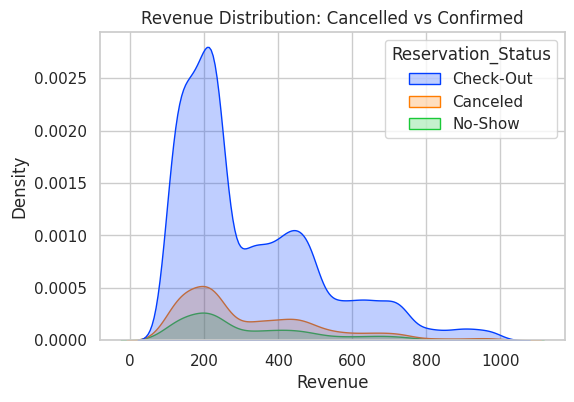

In [40]:
#Revenue Distribution (Cancelled vs Confirmed)

# Ensure date columns are in datetime format if they haven't been already
train['Expected_checkin'] = pd.to_datetime(train['Expected_checkin'])
train['Expected_checkout'] = pd.to_datetime(train['Expected_checkout'])

# Calculate Length_of_Stay
train['Length_of_Stay'] = (train['Expected_checkout'] - train['Expected_checkin']).dt.days

train["Revenue"] = train["Room_Rate"] * train["Length_of_Stay"]

plt.figure(figsize=(6,4))

sns.kdeplot(
    data=train,
    x="Revenue",
    hue="Reservation_Status",
    palette="bright",
    fill=True
)

plt.title("Revenue Distribution: Cancelled vs Confirmed")

plt.show()

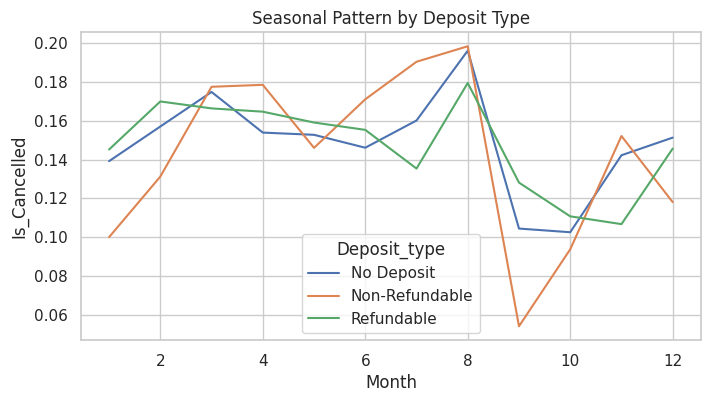

In [41]:
#Seasonal Pattern by Deposit Type

# Ensure 'Expected_checkin' is datetime (already done in previous cells, but good to be explicit)
train['Expected_checkin'] = pd.to_datetime(train['Expected_checkin'])

# Extract Month from Expected_checkin
train['Month'] = train['Expected_checkin'].dt.month

# Create Is_Cancelled column
train['Is_Cancelled'] = train['Reservation_Status'].apply(lambda x: 1 if x == 'Canceled' else 0)

seasonal = train.groupby(["Month","Deposit_type"])["Is_Cancelled"].mean().reset_index()

plt.figure(figsize=(8,4))

sns.lineplot(
    data=seasonal,
    x="Month",
    y="Is_Cancelled",
    hue="Deposit_type"
)

plt.title("Seasonal Pattern by Deposit Type")

plt.show()

/tmp/ipykernel_8294/443552187.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot2 = pd.pivot_table(


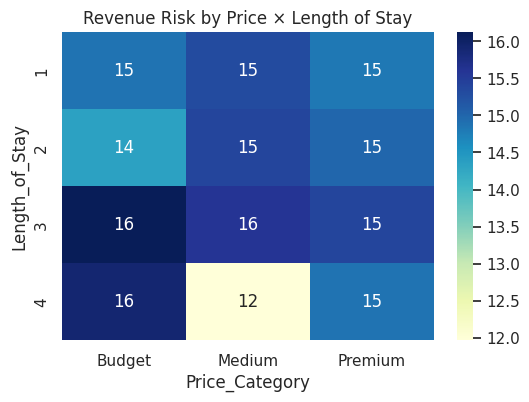

In [42]:
#Revenue at Risk by Price × Length of Stay
train["Price_Category"] = pd.cut(
    train["Room_Rate"],
    bins=[0,150,200,300],
    labels=["Budget","Medium","Premium"]
)

pivot2 = pd.pivot_table(
    train,
    values="Is_Cancelled",
    index="Length_of_Stay",
    columns="Price_Category",
    aggfunc="mean"
)

plt.figure(figsize=(6,4))

sns.heatmap(
    pivot2*100,
    annot=True,
    cmap="YlGnBu"
)

plt.title("Revenue Risk by Price × Length of Stay")

plt.show()

/tmp/ipykernel_8294/1361529166.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot3 = pd.pivot_table(


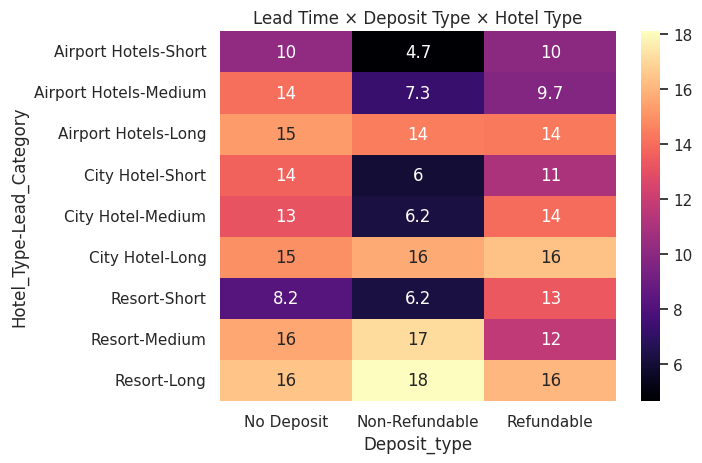

In [43]:
#Lead Time × Deposit Type × Hotel Type

# Create 'Lead_Category' column from 'Lead_Time'
train['Lead_Category'] = pd.cut(
    train['Lead_Time'],
    bins=[float('-inf'), 7, 30, float('inf')],
    labels=['Short', 'Medium', 'Long']
)

pivot3 = pd.pivot_table(
    train,
    values="Is_Cancelled",
    index=["Hotel_Type","Lead_Category"],
    columns="Deposit_type", # Corrected column name
    aggfunc="mean"
)

sns.heatmap(
    pivot3*100,
    annot=True,
    cmap="magma"
)

plt.title("Lead Time × Deposit Type × Hotel Type")

plt.show()

In [45]:
#Validation
#Reservation Status Distribution
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
validation = pd.read_csv("Hotel-A-validation.csv")

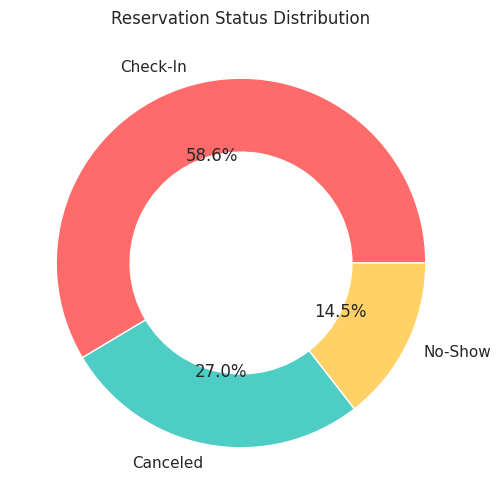

In [46]:
status = validation["Reservation_Status"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    status,
    labels=status.index,
    autopct='%1.1f%%',
    wedgeprops={'width':0.4},
    colors=["#ff6b6b","#4ecdc4","#ffd166"]
)

plt.title("Reservation Status Distribution")

plt.show()

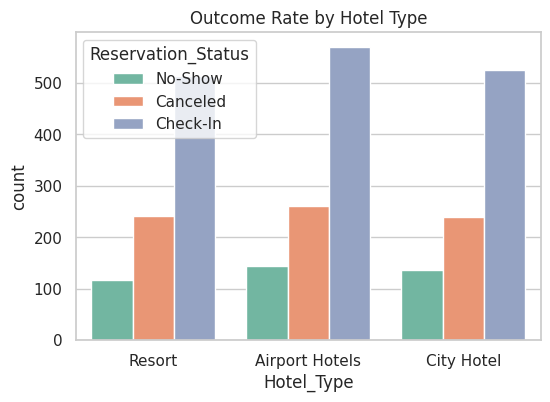

In [50]:
#Outcome Rate by Hotel Type
plt.figure(figsize=(6,4))

sns.countplot(
    x="Hotel_Type",
    hue="Reservation_Status",
    data=validation,
    palette="Set2"
)

plt.title("Outcome Rate by Hotel Type")
plt.show()

/tmp/ipykernel_8294/3291233694.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


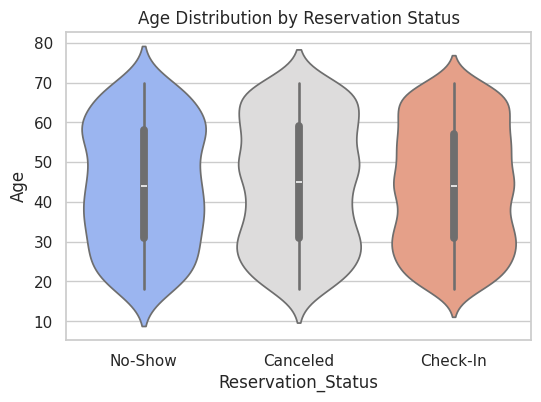

In [47]:
#Age by Reservation Status
plt.figure(figsize=(6,4))

sns.violinplot(
    x="Reservation_Status",
    y="Age",
    data=validation,
    palette="coolwarm"
)

plt.title("Age Distribution by Reservation Status")

plt.show()

/tmp/ipykernel_8294/1765866792.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


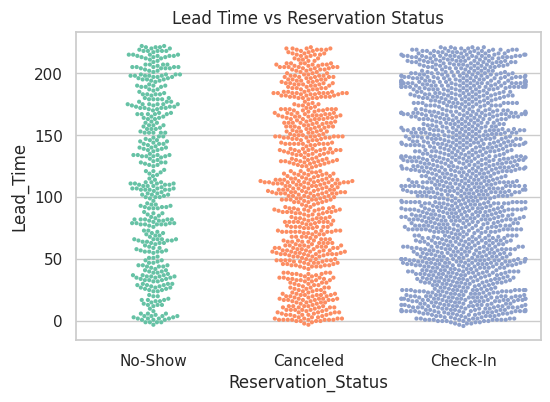

In [49]:
#Lead Time vs Reservation Status

# Convert date columns to datetime objects first for the validation dataset
validation['Expected_checkin'] = pd.to_datetime(validation['Expected_checkin'])
validation['Booking_date'] = pd.to_datetime(validation['Booking_date'])

# Calculate Lead_Time in days for the validation dataset
validation['Lead_Time'] = (validation['Expected_checkin'] - validation['Booking_date']).dt.days

plt.figure(figsize=(6,4))

sns.swarmplot(
    x="Reservation_Status",
    y="Lead_Time",
    data=validation,
    palette="Set2",
    size=3
)

plt.title("Lead Time vs Reservation Status")

plt.show()

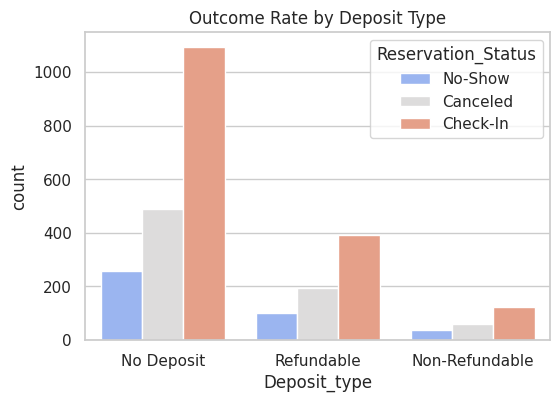

In [52]:
#Outcome Rate by Deposit Type
plt.figure(figsize=(6,4))

sns.countplot(
    x="Deposit_type",
    hue="Reservation_Status",
    data=validation,
    palette="coolwarm"
)

plt.title("Outcome Rate by Deposit Type")
plt.show()

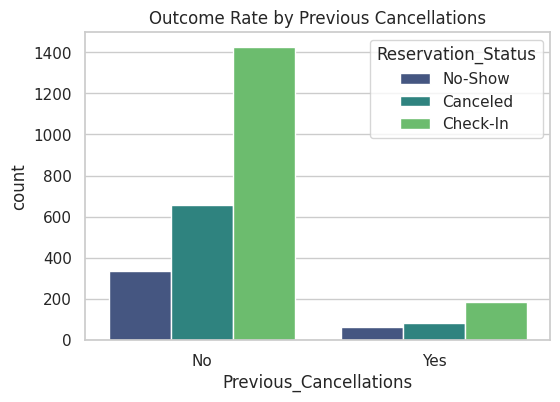

In [53]:
#Outcome Rate by Previous Cancellations
plt.figure(figsize=(6,4))

sns.countplot(
    x="Previous_Cancellations",
    hue="Reservation_Status",
    data=validation,
    palette="viridis"
)

plt.title("Outcome Rate by Previous Cancellations")
plt.show()

/tmp/ipykernel_8294/853283329.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


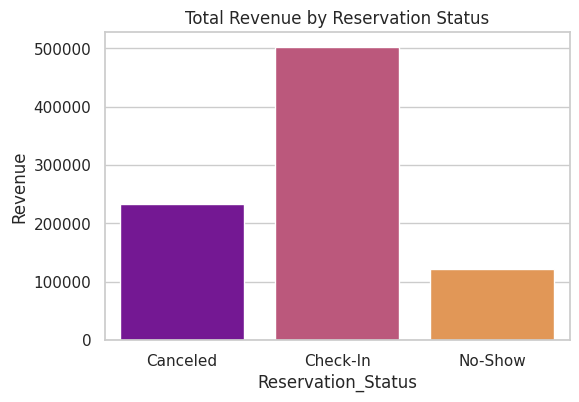

In [55]:
#Further EDA
#Total Revenue by Reservation Status

# Ensure date columns are in datetime format if they haven't been already
validation['Expected_checkin'] = pd.to_datetime(validation['Expected_checkin'])
validation['Expected_checkout'] = pd.to_datetime(validation['Expected_checkout'])

# Calculate Length_of_Stay
validation['Length_of_Stay'] = (validation['Expected_checkout'] - validation['Expected_checkin']).dt.days

validation["Revenue"] = validation["Room_Rate"] * validation["Length_of_Stay"]

revenue_status = validation.groupby("Reservation_Status")["Revenue"].sum()

plt.figure(figsize=(6,4))

sns.barplot(
    x=revenue_status.index,
    y=revenue_status.values,
    palette="plasma"
)

plt.title("Total Revenue by Reservation Status")
plt.ylabel("Revenue")

plt.show()

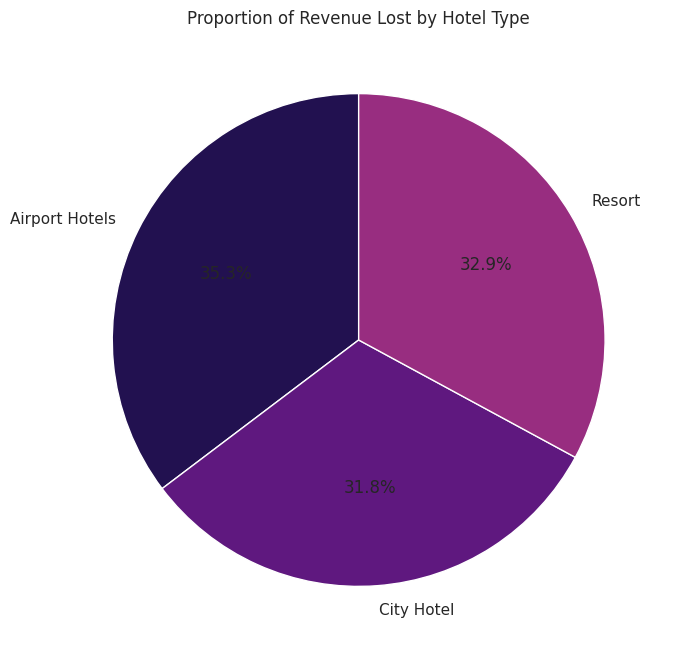

In [57]:
# Calculate revenue loss by hotel type for a pie chart
cancelled_validation = validation[validation["Reservation_Status"]=="Canceled"]
loss_by_hotel_type = cancelled_validation.groupby("Hotel_Type")["Revenue"].sum()

plt.figure(figsize=(8, 8))
plt.pie(
    loss_by_hotel_type.values,
    labels=loss_by_hotel_type.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette("magma")
)
plt.title("Proportion of Revenue Lost by Hotel Type")
plt.ylabel("") # Hide the y-label for pie chart
plt.show()

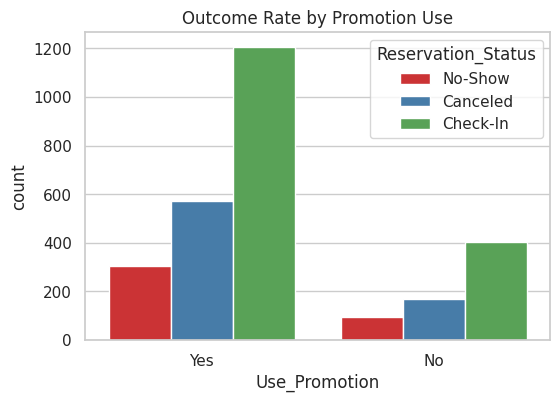

In [59]:
#Outcome Rate by Promotion Use
plt.figure(figsize=(6,4))

sns.countplot(
    x="Use_Promotion",
    hue="Reservation_Status",
    data=validation,
    palette="Set1"
)

plt.title("Outcome Rate by Promotion Use")

plt.show()

/tmp/ipykernel_8294/3420171525.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


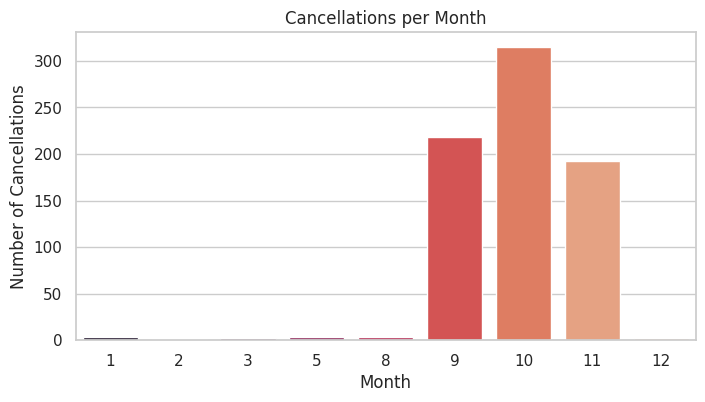

In [61]:
# Cancellations per Month
validation['Month'] = validation['Expected_checkin'].dt.month

cancel = validation[validation["Reservation_Status"]=="Canceled"]

if not cancel.empty:
    month_cancel = cancel.groupby("Month").size()

    plt.figure(figsize=(8,4))
    sns.barplot(
        x=month_cancel.index,
        y=month_cancel.values,
        palette="rocket"
    )
    plt.title("Cancellations per Month")
    plt.ylabel("Number of Cancellations")
    plt.show()
else:
    print("No 'Canceled' reservations found in the validation dataset to plot.")

In [62]:
#Test dataset
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

test = pd.read_csv("Hotel-A-test.csv")

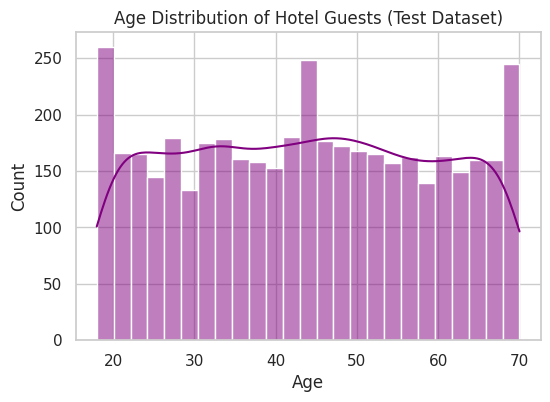

In [64]:
#UNIVARIATE ANALYSIS
# Age Distribution
plt.figure(figsize=(6,4))

sns.histplot(
    test["Age"],
    bins=25,
    kde=True,
    color="purple"
)

plt.title("Age Distribution of Hotel Guests (Test Dataset)")
plt.show()

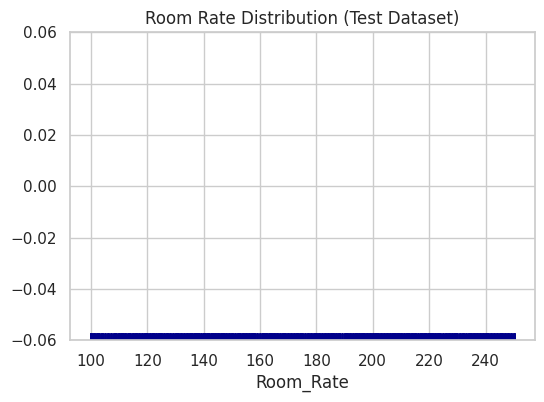

In [65]:
#Room Rate Distribution
plt.figure(figsize=(6,4))

sns.rugplot(
    x=test["Room_Rate"],
    color="darkblue"
)

plt.title("Room Rate Distribution (Test Dataset)")
plt.show()

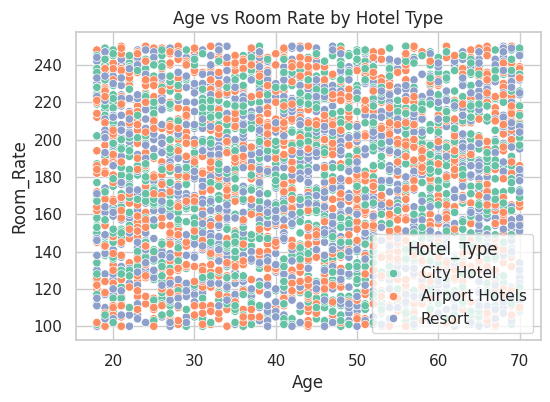

In [67]:
#BIVARIATE ANALYSIS
# Age vs Room Rate
plt.figure(figsize=(6,4))

sns.scatterplot(
    x="Age",
    y="Room_Rate",
    hue="Hotel_Type",
    data=test,
    palette="Set2"
)

plt.title("Age vs Room Rate by Hotel Type")
plt.show()

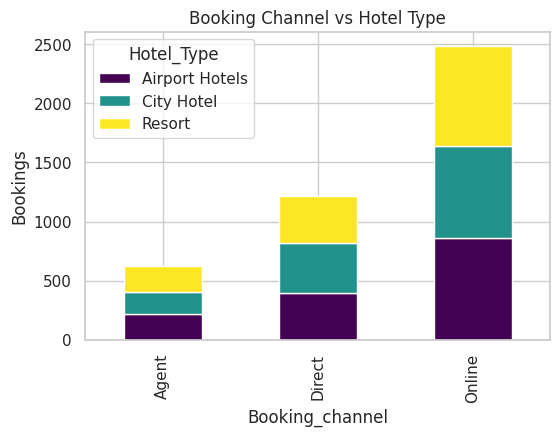

In [68]:
#Booking Channel vs Hotel Type
ct = pd.crosstab(test["Booking_channel"], test["Hotel_Type"])

ct.plot(
    kind="bar",
    stacked=True,
    colormap="viridis",
    figsize=(6,4)
)

plt.title("Booking Channel vs Hotel Type")
plt.ylabel("Bookings")
plt.show()

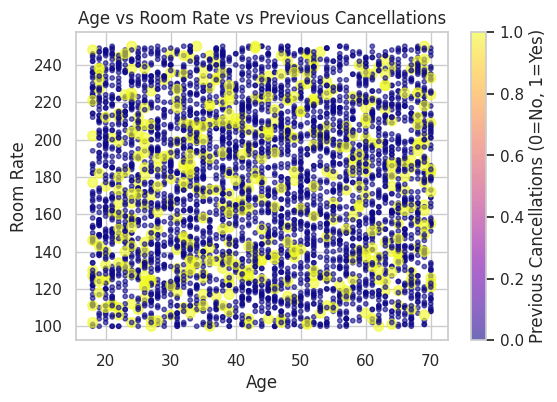

In [70]:
#MULTIVARIATE ANALYSIS
#Age × Room Rate × Previous Cancellations
plt.figure(figsize=(6,4))

# Convert 'Previous_Cancellations' from 'Yes'/'No' to 1/0 for numerical operations
test['Previous_Cancellations_Numeric'] = test['Previous_Cancellations'].map({'Yes': 1, 'No': 0})

plt.scatter(
    test["Age"],
    test["Room_Rate"],
    s=test["Previous_Cancellations_Numeric"]*40 + 10, # Use the new numeric column
    c=test["Previous_Cancellations_Numeric"], # Use the new numeric column
    cmap="plasma",
    alpha=0.6
)

plt.xlabel("Age")
plt.ylabel("Room Rate")

plt.title("Age vs Room Rate vs Previous Cancellations")

plt.colorbar(label="Previous Cancellations (0=No, 1=Yes)")
plt.show()

In [73]:
print(test.columns)

Index(['Reservation-id', 'Gender', 'Age', 'Ethnicity', 'Educational_Level',
       'Income', 'Country_region', 'Hotel_Type', 'Expected_checkin',
       'Expected_checkout', 'Booking_date', 'Adults', 'Children', 'Babies',
       'Meal_Type', 'Visted_Previously', 'Previous_Cancellations',
       'Deposit_type', 'Booking_channel', 'Required_Car_Parking',
       'Use_Promotion', 'Discount_Rate', 'Room_Rate',
       'Previous_Cancellations_Numeric'],
      dtype='object')


In [75]:
# convert to datetime
test["Booking_date"] = pd.to_datetime(test["Booking_date"])
test["Expected_checkin"] = pd.to_datetime(test["Expected_checkin"])

# create Lead_Time
test["Lead_Time"] = (test["Expected_checkin"] - test["Booking_date"]).dt.days

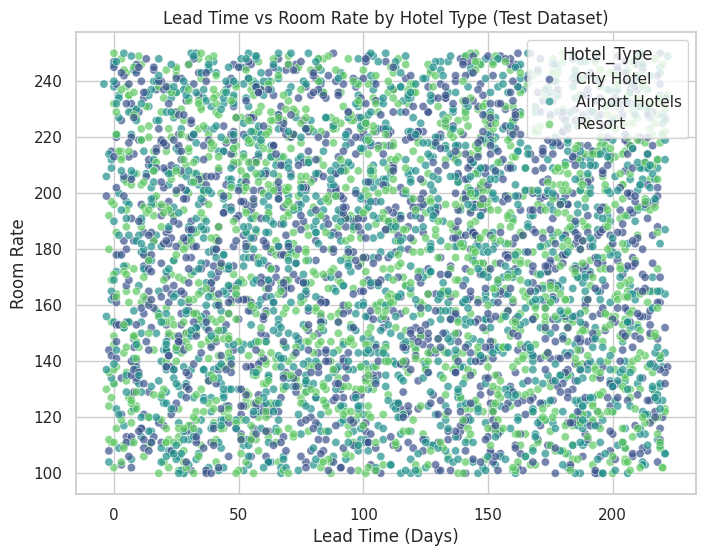

In [78]:
#Lead Time vs Room Rate
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x="Lead_Time",
    y="Room_Rate",
    hue="Hotel_Type",
    data=test,
    palette="viridis",
    alpha=0.7
)
plt.title("Lead Time vs Room Rate by Hotel Type (Test Dataset)")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Room Rate")
plt.show()

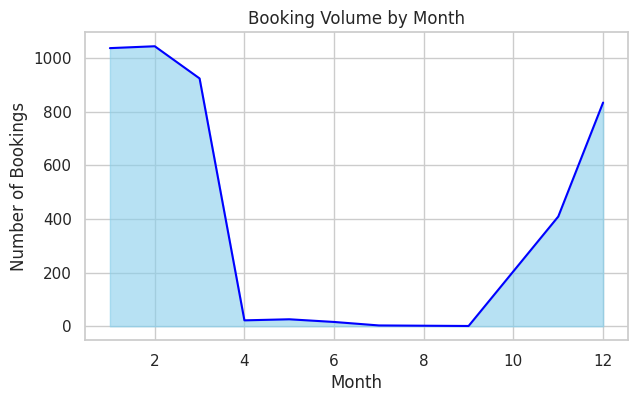

In [80]:
#Further EDA
#Booking Volume by Month
# Ensure 'Expected_checkin' is datetime (already done in previous cells, but good to be explicit)
test['Expected_checkin'] = pd.to_datetime(test['Expected_checkin'])

# Extract Month from Expected_checkin
test['Month'] = test['Expected_checkin'].dt.month

month_counts = test["Month"].value_counts().sort_index()

plt.figure(figsize=(7,4))

plt.fill_between(
    month_counts.index,
    month_counts.values,
    color="skyblue",
    alpha=0.6
)

plt.plot(month_counts.index, month_counts.values, color="blue")

plt.title("Booking Volume by Month")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")

plt.show()

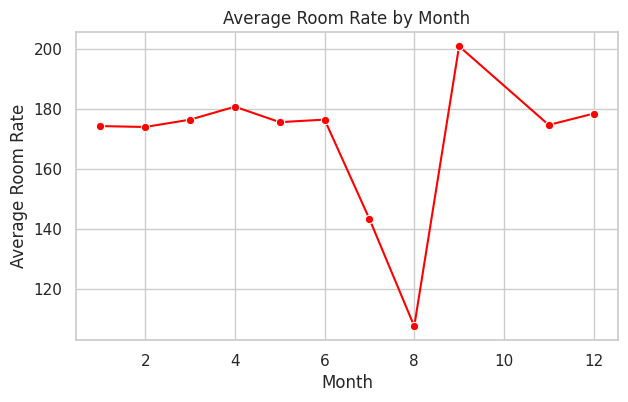

In [81]:
#Average Room Rate by Month
avg_rate = test.groupby("Month")["Room_Rate"].mean()

plt.figure(figsize=(7,4))

sns.lineplot(
    x=avg_rate.index,
    y=avg_rate.values,
    marker="o",
    color="red"
)

plt.title("Average Room Rate by Month")
plt.xlabel("Month")
plt.ylabel("Average Room Rate")

plt.show()

/tmp/ipykernel_8294/3675210175.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


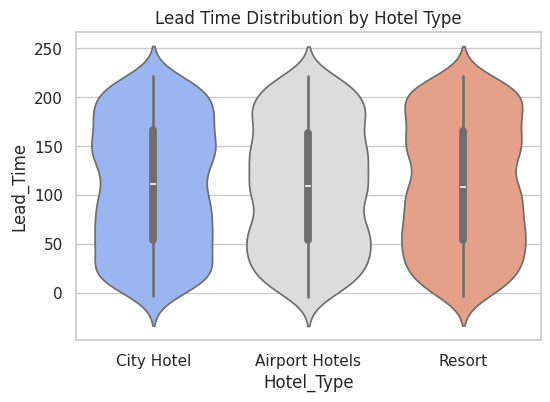

In [82]:
#Lead Time vs Hotel Type
plt.figure(figsize=(6,4))

sns.violinplot(
    x="Hotel_Type",
    y="Lead_Time",
    data=test,
    palette="coolwarm"
)

plt.title("Lead Time Distribution by Hotel Type")
plt.show()

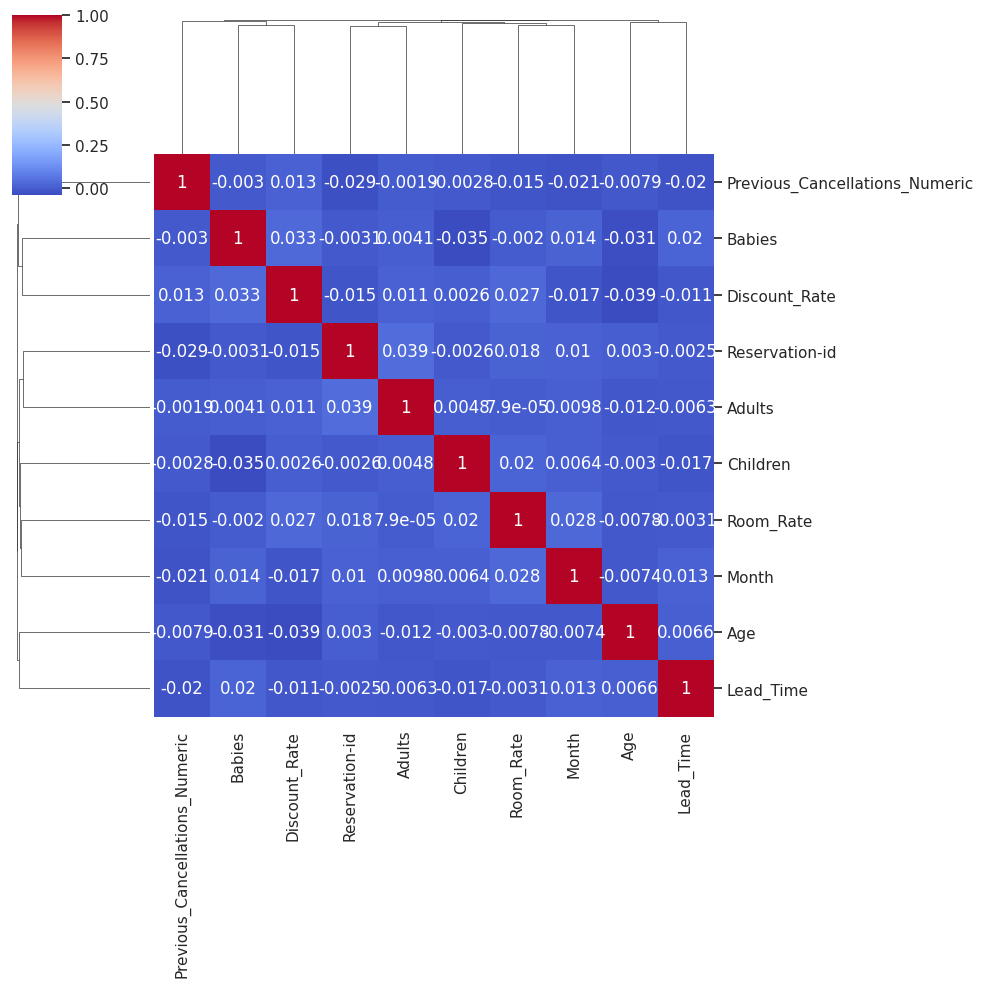

In [83]:
#Correlation Matrix (Cluster Heatmap)
corr = test.corr(numeric_only=True)

sns.clustermap(
    corr,
    cmap="coolwarm",
    annot=True
)